In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('insurance.csv')


In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print(df.shape)

(1338, 7)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

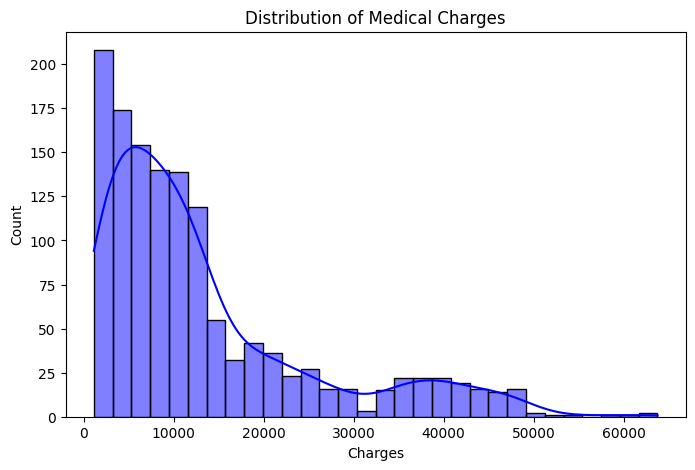

In [8]:
# Chart 1 - Distribution of medical charges
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], bins=30, kde=True, color='blue')
plt.title('Distribution of Medical Charges')
plt.xlabel('Charges')
plt.ylabel('Count')
plt.show()

/var/folders/zl/m0vxrqgj4mgg3_ktrvwsvt2r0000gn/T/ipykernel_31118/2708795662.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')


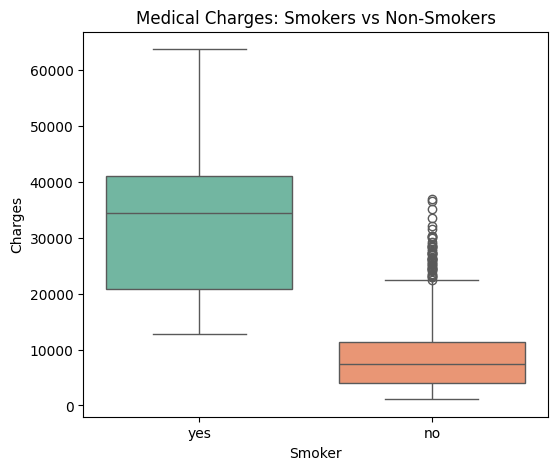

In [9]:
# Chart 2 - Smoker vs Charges
plt.figure(figsize=(6,5))
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')
plt.title('Medical Charges: Smokers vs Non-Smokers')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

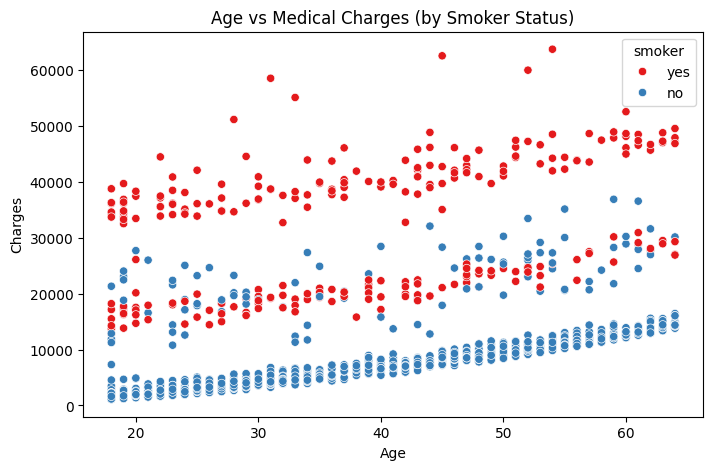

In [10]:
# Chart 3 - Age vs Charges
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, palette='Set1')
plt.title('Age vs Medical Charges (by Smoker Status)')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

In [11]:
# Convert text columns to numbers
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
print(df_encoded.columns.tolist())
print(df_encoded.shape)

['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']
(1338, 9)


In [12]:
# X = inputs, Y = what we want to predict
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1338, 8)
y shape: (1338,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (1070, 8)
Testing size: (268, 8)


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Create and train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Test the model
y_pred_lr = lr_model.predict(X_test)

# Measure how good it is
mae = mean_absolute_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print(f"MAE: ${mae:,.2f}")
print(f"R2 Score: {r2:.4f}")

Linear Regression Results:
MAE: $4,181.19
R2 Score: 0.7836


In [15]:
from sklearn.linear_model import Ridge, Lasso

# Ridge model
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

# Lasso model
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

# Compare all 3
print("Linear Regression - MAE: ${:,.2f} | R2: {:.4f}".format(
    mean_absolute_error(y_test, y_pred_lr), r2_score(y_test, y_pred_lr)))

print("Ridge             - MAE: ${:,.2f} | R2: {:.4f}".format(
    mean_absolute_error(y_test, y_pred_ridge), r2_score(y_test, y_pred_ridge)))

print("Lasso             - MAE: ${:,.2f} | R2: {:.4f}".format(
    mean_absolute_error(y_test, y_pred_lasso), r2_score(y_test, y_pred_lasso)))

Linear Regression - MAE: $4,181.19 | R2: 0.7836
Ridge             - MAE: $4,193.59 | R2: 0.7833
Lasso             - MAE: $4,182.43 | R2: 0.7835


In [16]:
import joblib

# Save the model
joblib.dump(lr_model, 'medical_cost_model.pkl')
print("Model saved!")

Model saved!
